<a href="https://colab.research.google.com/github/sumaiyaSultanaTarin/Leukocyte-and-AML-segmentation/blob/main/aml_phase_i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase-A**

Environment setup

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed):
      random.seed(seed)
      np.random.seed(seed)
      torch.manual_seed(seed)
      torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/AML_segmentation_project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
LOG_DIR = os.path.join(PROJECT_DIR, "logs")

for d in [DATA_DIR, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Data dir:", DATA_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Log dir:", LOG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/AML_segmentation_project
Data dir: /content/drive/MyDrive/AML_segmentation_project/data
Checkpoint dir: /content/drive/MyDrive/AML_segmentation_project/checkpoints
Log dir: /content/drive/MyDrive/AML_segmentation_project/logs


Install Packages

In [ ]:
!pip install -q segmentation-models-pytorch albumentations huggingface_hub


Download and inspect WBCAtt+

In [ ]:
from huggingface_hub import hf_hub_download
import tarfile
import os

LOCAL_DATA_DIR = "/content/data"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

tar_path = hf_hub_download(
      repo_id="apple2373/wbcattplus",
      filename="pbcseg_final_v1.tar",
      repo_type="dataset",
      local_dir=LOCAL_DATA_DIR,
  )

print("Downloaded to:", tar_path)

with tarfile.open(tar_path) as tar:
      tar.extractall(LOCAL_DATA_DIR)

print("\nExtracted contents of", LOCAL_DATA_DIR, ":")
for root, dirs, files in os.walk(LOCAL_DATA_DIR):
      depth = root.replace(LOCAL_DATA_DIR, "").count(os.sep)
      if depth > 2:
          continue
      indent = "  " * depth
      print(f"{indent}{os.path.basename(root)}/")
      for f in files[:5]:
          print(f"{indent}  {f}")
      if len(files) > 5:
          print(f"{indent}  ... ({len(files)} files total)")

Downloaded to: /content/data/pbcseg_final_v1.tar


/tmp/ipykernel_19941/781725178.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(LOCAL_DATA_DIR)



Extracted contents of /content/data :
data/
  pbcseg_final_v1.tar
  pbcseg_final_v1/
    BNE_831588_ccrop_mask.png
    BA_537842_ccrop.jpg
    LY_205694_ccrop.jpg
    EO_511115_ccrop_mask.png
    LY_776538_ccrop_mask.png
    ... (20596 files total)
  .cache/
    huggingface/
      CACHEDIR.TAG
      .gitignore


Get the official split + inspect mask values

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import glob

base_url = "https://raw.githubusercontent.com/apple2373/wbcattplus/main/dataset_txt/"
split_csv_url = base_url + "pbc_attr_v1_ccrop_all.csv"

split_df = pd.read_csv(split_csv_url)

print("Split counts:")
print(split_df["split"].value_counts())
print("\nFirst few rows:")
print(split_df[["img_name", "split"]].head())

mask_paths = glob.glob(f"{LOCAL_DATA_DIR}/pbcseg_final_v1/*_mask.png")
sample_mask = np.array(Image.open(mask_paths[0]))

print("\nSample mask file:", mask_paths[0])
print("Mask shape:", sample_mask.shape)
print("Unique pixel values:", np.unique(sample_mask))

Split counts:
split
train    6169
test     3099
val      1030
Name: count, dtype: int64

First few rows:
             img_name  split
0  BNE_7323_ccrop.jpg  train
1  BNE_7938_ccrop.jpg  train
2  BNE_8741_ccrop.jpg  train
3  BNE_9071_ccrop.jpg  train
4  BNE_9373_ccrop.jpg  train

Sample mask file: /content/data/pbcseg_final_v1/BNE_831588_ccrop_mask.png
Mask shape: (360, 360)
Unique pixel values: [0 1 2 4]


**Phase-B**

Class remap, sanity-checked on the sample mask

Raw unique values: [0 1 2 4]
Remapped unique values: [0 1 2]


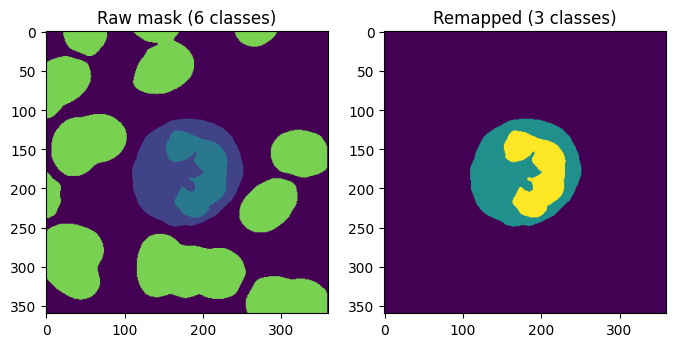

In [ ]:
import matplotlib.pyplot as plt

# raw value -> 3-class label (0=background, 1=cytoplasm, 2=nucleus)
REMAP = np.array([0, 1, 2, 0, 0, 1], dtype=np.uint8)

def remap_mask(raw_mask):
      return REMAP[raw_mask]

remapped = remap_mask(sample_mask)

print("Raw unique values:", np.unique(sample_mask))
print("Remapped unique values:", np.unique(remapped))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_mask, vmin=0, vmax=5)
axes[0].set_title("Raw mask (6 classes)")
axes[1].imshow(remapped, vmin=0, vmax=2)
axes[1].set_title("Remapped (3 classes)")
plt.show()

Dataset class (no augmentation yet)

In [ ]:
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

basic_transform = A.Compose([
      A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
      ToTensorV2(),
])


class WBCAttDataset(Dataset):
    def __init__(self, split_df, split_name, image_dir, transform):
          self.df = split_df[split_df["split"] == split_name].reset_index(drop=True)
          self.image_dir = image_dir
          self.transform = transform

    def __len__(self):
          return len(self.df)

    def __getitem__(self, idx):
          img_name = self.df.loc[idx, "img_name"]
          image_path = self.image_dir + "/" + img_name
          mask_path = image_path.replace(".jpg", "_mask.png")

          image = np.array(Image.open(image_path).convert("RGB"))
          raw_mask = np.array(Image.open(mask_path))
          mask = remap_mask(raw_mask)

          transformed = self.transform(image=image, mask=mask)
          image_tensor = transformed["image"]
          mask_tensor = transformed["mask"].long()

          return image_tensor, mask_tensor


image_dir = LOCAL_DATA_DIR + "/pbcseg_final_v1"
train_dataset = WBCAttDataset(split_df, "train", image_dir, basic_transform)

print("Train dataset size:", len(train_dataset))
img, msk = train_dataset[0]
print("Image tensor shape:", img.shape, img.dtype)
print("Mask tensor shape:", msk.shape, msk.dtype)
print("Mask unique values:", torch.unique(msk))

Train dataset size: 6169
Image tensor shape: torch.Size([3, 360, 360]) torch.float32
Mask tensor shape: torch.Size([360, 360]) torch.int64
Mask unique values: tensor([0, 1, 2])


Augmentation + DataLoaders

In [ ]:
import cv2
from torch.utils.data import DataLoader

train_transform = A.Compose([
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5),
      A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT,
                fill=0, fill_mask=0, p=0.5),
      A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.5),
      A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
      ToTensorV2(),
])

train_dataset = WBCAttDataset(split_df, "train", image_dir, train_transform)
val_dataset = WBCAttDataset(split_df, "val", image_dir, basic_transform)
test_dataset = WBCAttDataset(split_df, "test", image_dir, basic_transform)

print("train:", len(train_dataset), "val:", len(val_dataset), "test:",
len(test_dataset))

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True, persistent_workers=True)

images, masks = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)
print("Batch mask unique values:", torch.unique(masks))

train: 6169 val: 1030 test: 3099
Batch image shape: torch.Size([16, 3, 360, 360])
Batch mask shape: torch.Size([16, 360, 360])
Batch mask unique values: tensor([0, 1, 2])


**Phase-C**

Model with RFG init

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp


class RatioFeedbackGate(nn.Module):
      def __init__(self, channels, hidden=8, epsilon=1e-6, init_bias=-4.0):
          super().__init__()
          self.epsilon = epsilon
          self.probe_head = nn.Conv2d(channels, 3, kernel_size=1)
          self.fc1 = nn.Linear(1, hidden)
          self.fc2 = nn.Linear(hidden, channels)

          nn.init.zeros_(self.fc2.weight)
          nn.init.constant_(self.fc2.bias, init_bias)

          self.last_ratio = None
          self.last_gate_mean = None

      def forward(self, x):
          probe = F.softmax(self.probe_head(x), dim=1)
          nuc_area = probe[:, 2, :, :].sum(dim=[1, 2])
          cyto_area = probe[:, 1, :, :].sum(dim=[1, 2])
          ratio = torch.log((nuc_area + self.epsilon) / (cyto_area + self.epsilon))
          self.last_ratio = ratio

          h = F.relu(self.fc1(ratio.unsqueeze(1)))
          gate = torch.sigmoid(self.fc2(h))
          self.last_gate_mean = gate.mean().item()

          gate = gate.view(gate.size(0), gate.size(1), 1, 1)
          return x + x * gate


class SegModel(nn.Module):
      def __init__(self, backbone, num_classes=3, use_rfg=True):
          super().__init__()
          if backbone == "attention_unet":
              base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                               decoder_attention_type="scse", in_channels=3,
classes=num_classes)
          elif backbone == "unet":
              base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                               in_channels=3, classes=num_classes)
          else:
              raise ValueError("unknown backbone: " + backbone)

          self.encoder = base.encoder
          self.decoder = base.decoder
          self.seg_head = base.segmentation_head
          self.use_rfg = use_rfg
          if use_rfg:
              channels = self.seg_head[0].in_channels
              self.rfg = RatioFeedbackGate(channels)

      def forward(self, x):
          features = self.encoder(x)
          d = self.decoder(features)
          if self.use_rfg:
              d = self.rfg(d)
          return self.seg_head(d)

model = SegModel("attention_unet", num_classes=3, use_rfg=True).to(device)
images_gpu = images.to(device)

with torch.no_grad():
      output = model(images_gpu)

print("Output shape:", output.shape)
print("Gate mean at init:", model.rfg.last_gate_mean)

Output shape: torch.Size([16, 3, 360, 360])
Gate mean at init: 0.01798621006309986


Losses + λ2 ramp schedule

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
          super().__init__()
          self.epsilon = epsilon

    def forward(self, logits, targets):
          probs = F.softmax(logits, dim=1)
          num_classes = probs.shape[1]
          targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
          dims = (0, 2, 3)
          intersection = torch.sum(probs * targets_onehot, dims)
          union = torch.sum(probs + targets_onehot, dims)
          dice_per_class = (2 * intersection + self.epsilon) / (union + self.epsilon)
          return 1 - dice_per_class.mean()


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
          super().__init__()
          self.gamma = gamma

    def forward(self, logits, targets):
          ce = F.cross_entropy(logits, targets, reduction="none")
          pt = torch.exp(-ce)
          return (((1 - pt) ** self.gamma) * ce).mean()


class RatioConsistencyLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
          super().__init__()
          self.epsilon = epsilon
          self.huber = nn.HuberLoss()

    def true_log_ratio(self, targets):
          true_nuc = (targets == 2).float().sum(dim=[1, 2])
          true_cyto = (targets == 1).float().sum(dim=[1, 2])
          return torch.log((true_nuc + self.epsilon) / (true_cyto + self.epsilon))

    def forward(self, logits, targets):
          probs = F.softmax(logits, dim=1)
          pred_nuc = probs[:, 2, :, :].sum(dim=[1, 2])
          pred_cyto = probs[:, 1, :, :].sum(dim=[1, 2])
          pred_ratio = torch.log((pred_nuc + self.epsilon) / (pred_cyto + self.epsilon))
          true_ratio = self.true_log_ratio(targets)
          return self.huber(pred_ratio, true_ratio)


def lambda2_ramp(epoch, total_epochs, target=0.3, ramp_fraction=0.25):
      """Linearly ramps the ratio-loss weight from 0 to target over the
      first `ramp_fraction` of training, instead of applying full weight
      from epoch 1."""
      ramp_epochs = max(1, int(total_epochs * ramp_fraction))
      if epoch >= ramp_epochs:
          return target
      return target * (epoch / ramp_epochs)


class TotalLoss(nn.Module):
    def __init__(self, lambda1=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.ratio = RatioConsistencyLoss()
        self.rfg_huber = nn.HuberLoss()
        self.lambda1 = lambda1

    def forward(self, logits, targets, lambda2, lambda3=0.0, rfg_ratio=None):
        loss = self.dice(logits, targets) + self.lambda1 * self.focal(logits, targets)
        if lambda2 > 0:
            loss = loss + lambda2 * self.ratio(logits, targets)
        if rfg_ratio is not None and lambda3 > 0:
            true_ratio = self.ratio.true_log_ratio(targets)
            loss = loss + lambda3 * self.rfg_huber(rfg_ratio, true_ratio)
        return loss


masks_gpu = masks.to(device)
loss_fn = TotalLoss()

lambda2_epoch0 = lambda2_ramp(epoch=0, total_epochs=20)
lambda2_epoch10 = lambda2_ramp(epoch=10, total_epochs=20)
print("lambda2 at epoch 0:", lambda2_epoch0)
print("lambda2 at epoch 10:", lambda2_epoch10)

with torch.no_grad():
    output = model(images_gpu)
loss = loss_fn(output, masks_gpu, lambda2=lambda2_epoch0,
rfg_ratio=model.rfg.last_ratio)
print("Loss at epoch 0:", loss.item())

lambda2 at epoch 0: 0.0
lambda2 at epoch 10: 0.3
Loss at epoch 0: 1.2455339431762695


Small-subset setup + training/eval functions

In [ ]:
def evaluate(model, loader):
      model.eval()
      dice_metric = DiceLoss()
      total_dice = 0
      total_ratio_error = 0
      n_batches = 0

      with torch.no_grad():
          for imgs, msks in loader:
              imgs = imgs.to(device)
              msks = msks.to(device)
              logits = model(imgs)
              dice = 1 - dice_metric(logits, msks).item()

              probs = F.softmax(logits, dim=1)
              pred_nuc = probs[:, 2].sum(dim=[1, 2])
              pred_cyto = probs[:, 1].sum(dim=[1, 2])
              pred_ratio = torch.log((pred_nuc + 1e-6) / (pred_cyto + 1e-6))

              true_nuc = (msks == 2).float().sum(dim=[1, 2])
              true_cyto = (msks == 1).float().sum(dim=[1, 2])
              true_ratio = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))

              ratio_error = (pred_ratio - true_ratio).abs().mean().item()

              total_dice += dice
              total_ratio_error += ratio_error
              n_batches += 1

      avg_dice = total_dice / n_batches
      avg_ratio_error = total_ratio_error / n_batches
      return avg_dice, avg_ratio_error


def quick_train(use_rfg, use_ratio, seed, train_loader, val_loader, epochs=10):
      torch.manual_seed(seed)
      model = SegModel("attention_unet", use_rfg=use_rfg).to(device)
      loss_fn = TotalLoss()
      opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

      history = []
      for epoch in range(epochs):
          model.train()
          lambda2 = 0.0
          if use_ratio:
              lambda2 = lambda2_ramp(epoch, epochs)

          for imgs, msks in train_loader:
              imgs = imgs.to(device)
              msks = msks.to(device)
              opt.zero_grad()
              logits = model(imgs)
              rfg_ratio = None
              if use_rfg:
                  rfg_ratio = model.rfg.last_ratio
              loss = loss_fn(logits, msks, lambda2=lambda2, rfg_ratio=rfg_ratio)
              loss.backward()
              opt.step()

          val_dice, val_ratio_error = evaluate(model, val_loader)
          row = {"epoch": epoch, "val_dice": val_dice, "val_ratio_error":
  val_ratio_error}
          history.append(row)
          print("epoch", epoch, "dice", round(val_dice, 4), "ratio_error",
  round(val_ratio_error, 4))

      return history


print("functions defined")

functions defined


In [ ]:
import random as pyrandom
from torch.utils.data import Subset

pyrandom.seed(0)
train_idx = pyrandom.sample(range(len(train_dataset)), 600)
val_idx = pyrandom.sample(range(len(val_dataset)), 200)

small_train_loader = DataLoader(
      Subset(train_dataset, train_idx),
      batch_size=16,
      shuffle=True,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
)

small_val_loader = DataLoader(
      Subset(val_dataset, val_idx),
      batch_size=16,
      shuffle=False,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
)

print("train subset size", len(train_idx))
print("val subset size", len(val_idx))

train subset size 600
val subset size 200


**Phase-D**

full-size DataLoaders

In [ ]:
full_train_loader = DataLoader(
      train_dataset,
      batch_size=24,
      shuffle=True,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
  )

full_val_loader = DataLoader(
      val_dataset,
      batch_size=24,
      shuffle=False,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
  )

print("train batches per epoch:", len(full_train_loader))
print("val batches per epoch:", len(full_val_loader))

train batches per epoch: 258
val batches per epoch: 43


training function

In [ ]:
import os
import pandas as pd
from torch.amp import autocast, GradScaler

In [ ]:
def train_one_epoch(model, loader, loss_fn, opt, scaler, lambda2, lambda3, use_rfg):
      model.train()
      total_loss = 0
      n_batches = 0

      for imgs, msks in loader:
          imgs = imgs.to(device)
          msks = msks.to(device)
          opt.zero_grad()

          with autocast("cuda"):
            logits = model(imgs)
            rfg_ratio = None
            if use_rfg:
                rfg_ratio = model.rfg.last_ratio
            loss = loss_fn(logits, msks, lambda2=lambda2, lambda3=lambda3, rfg_ratio=rfg_ratio)

          scaler.scale(loss).backward()
          scaler.step(opt)
          scaler.update()

          total_loss += loss.item()
          n_batches += 1

      return total_loss / n_batches

In [ ]:
def run_experiment(backbone, use_rfg, use_ratio, seed,
                    train_loader, val_loader,
                    max_epochs=50, patience=8):

    torch.manual_seed(seed)

    run_name = backbone
    run_name += "_rfg" + str(int(use_rfg))
    run_name += "_ratio" + str(int(use_ratio))
    run_name += "_seed" + str(seed)

    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR, run_name + "_state.pt")

    model = SegModel(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    loss_fn = TotalLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    scaler = GradScaler("cuda")

    start_epoch = 0
    best_dice = 0
    best_ratio_error = float("inf")
    epochs_no_improve = 0
    history = []

    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state["model"])
        opt.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        start_epoch = state["epoch"]
        best_dice = state["best_dice"]
        best_ratio_error = state["best_ratio_error"]
        epochs_no_improve = state["epochs_no_improve"]
        history = state["history"]
        print("resuming", run_name, "from epoch", start_epoch)
    else:
        print("starting", run_name)

    for epoch in range(start_epoch, max_epochs):
        lambda2 = 0.0
        if use_ratio:
            lambda2 = lambda2_ramp(epoch, max_epochs)

        lambda3 = 0.0
        if use_rfg:
            lambda3 = lambda2_ramp(epoch, max_epochs)

        train_loss = train_one_epoch(model, train_loader, loss_fn, opt, scaler,
                                      lambda2, lambda3, use_rfg)
        scheduler.step()

        val_dice, val_ratio_error = evaluate(model, val_loader)
        gate_mean = model.rfg.last_gate_mean if use_rfg else None
        print("epoch", epoch + 1, "train_loss", round(train_loss, 4),
              "val_dice", round(val_dice, 4), "val_ratio_error",
              round(val_ratio_error, 4), "gate_mean", gate_mean)

        history.append({"epoch": epoch + 1, "train_loss": train_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error,
                         "gate_mean": gate_mean})

        if val_ratio_error < best_ratio_error:
            best_dice = val_dice
            best_ratio_error = val_ratio_error
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        state = {"model": model.state_dict(), "optimizer": opt.state_dict(),
                 "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                 "epoch": epoch + 1, "best_dice": best_dice,
                 "best_ratio_error": best_ratio_error,
                 "epochs_no_improve": epochs_no_improve, "history": history}
        torch.save(state, state_path)

        if epochs_no_improve >= patience:
            print("early stopping at epoch", epoch + 1)
            break

    history_df = pd.DataFrame(history)
    history_path = os.path.join(LOG_DIR, run_name + "_history.csv")
    history_df.to_csv(history_path, index=False)

    if os.path.exists(state_path):
        os.remove(state_path)

    print("finished", run_name)
    print("best_dice", best_dice, "best_ratio_error", best_ratio_error)

    return {"run_name": run_name, "backbone": backbone, "use_rfg": use_rfg,
            "use_ratio": use_ratio, "seed": seed, "best_dice": best_dice,
            "best_ratio_error": best_ratio_error, "checkpoint_path": checkpoint_path,
            "history_path": history_path}


platform-agnostic

In [ ]:
def make_run_name(backbone, use_rfg, use_ratio, seed):
      name = backbone
      name += "_rfg" + str(int(use_rfg))
      name += "_ratio" + str(int(use_ratio))
      name += "_seed" + str(seed)
      return name


def maybe_run(backbone, use_rfg, use_ratio, seed, results_list):
      run_name = make_run_name(backbone, use_rfg, use_ratio, seed)
      checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")
      state_path = os.path.join(CHECKPOINT_DIR, run_name + "_state.pt")

      already_done = os.path.exists(checkpoint_path)
      in_progress = os.path.exists(state_path)

      if already_done and not in_progress:
          print("skipping, already finished:", run_name)
          return

      result = run_experiment(
          backbone=backbone,
          use_rfg=use_rfg,
          use_ratio=use_ratio,
          seed=seed,
          train_loader=full_train_loader,
          val_loader=full_val_loader,
          max_epochs=50,
          patience=8,
      )
      results_list.append(result)


assigned_seeds = [1, 2, 3, 4, 5]
batch_results = []

attn_configs = [
    (False, False),  # baseline
    (True, False),   # RFG only
    (False, True),   # ratio loss only
    (True, True),    # full method
]

for use_rfg, use_ratio in attn_configs:
    for seed in assigned_seeds:
        maybe_run("attention_unet", use_rfg, use_ratio, seed, batch_results)

for use_rfg in [False, True]:
    for seed in assigned_seeds:
        maybe_run("unet", use_rfg, True, seed, batch_results)

print("batch finished, runs completed this session:", len(batch_results))

skipping, already finished: attention_unet_rfg0_ratio0_seed1
skipping, already finished: attention_unet_rfg0_ratio0_seed2
skipping, already finished: attention_unet_rfg0_ratio0_seed3
skipping, already finished: attention_unet_rfg0_ratio0_seed4
skipping, already finished: attention_unet_rfg0_ratio0_seed5
skipping, already finished: attention_unet_rfg1_ratio0_seed1
skipping, already finished: attention_unet_rfg1_ratio0_seed2
skipping, already finished: attention_unet_rfg1_ratio0_seed3
skipping, already finished: attention_unet_rfg1_ratio0_seed4
skipping, already finished: attention_unet_rfg1_ratio0_seed5
skipping, already finished: attention_unet_rfg0_ratio1_seed1
skipping, already finished: attention_unet_rfg0_ratio1_seed2
skipping, already finished: attention_unet_rfg0_ratio1_seed3
skipping, already finished: attention_unet_rfg0_ratio1_seed4
skipping, already finished: attention_unet_rfg0_ratio1_seed5
skipping, already finished: attention_unet_rfg1_ratio1_seed1
skipping, already finish

**Phase-F**

Read results from LOG_DIR

In [ ]:
import glob
import re
import os
import pandas as pd

pattern_str = r"^(?P<backbone>.+)_rfg(?P<rfg>\d)_ratio(?P<ratio>\d)_seed(?P<seed>\d+)$"
run_name_pattern = re.compile(pattern_str)

rows = []
for history_path in sorted(glob.glob(os.path.join(LOG_DIR, "*_history.csv"))):
    run_name = os.path.basename(history_path).replace("_history.csv", "")
    match = run_name_pattern.match(run_name)
    if not match:
        print("skipping unrecognized file:", history_path)
        continue

    history_df = pd.read_csv(history_path)

    best_idx = history_df["val_ratio_error"].idxmin()
    best_row = history_df.loc[best_idx]

    rows.append({
        "backbone": match.group("backbone"),
        "use_rfg": bool(int(match.group("rfg"))),
        "use_ratio": bool(int(match.group("ratio"))),
        "seed": int(match.group("seed")),
        "best_epoch": int(best_row["epoch"]),
        "epochs_run": len(history_df),
        "best_dice": best_row["val_dice"],
        "best_ratio_error": best_row["val_ratio_error"],
    })

results_df = pd.DataFrame(rows).sort_values(
    ["backbone", "use_rfg", "use_ratio", "seed"]
).reset_index(drop=True)

results_df = results_df[results_df["seed"] != 999].reset_index(drop=True)

print(results_df.to_string(index=False))

print("")
print("=== per-config summary across seeds ===")
summary_df = results_df.groupby(["backbone", "use_rfg", "use_ratio"]).agg(
    n_seeds=("seed", "count"),
    mean_dice=("best_dice", "mean"),
    std_dice=("best_dice", "std"),
    mean_ratio_error=("best_ratio_error", "mean"),
    std_ratio_error=("best_ratio_error", "std"),
).reset_index()
print(summary_df.to_string(index=False))


      backbone  use_rfg  use_ratio  seed  best_epoch  epochs_run  best_dice  best_ratio_error
attention_unet    False      False     1          40          48   0.988771          0.029449
attention_unet    False      False     2          34          42   0.988402          0.030813
attention_unet    False      False     3          21          29   0.987666          0.030722
attention_unet    False      False     4          34          42   0.988603          0.028999
attention_unet    False      False     5          39          47   0.988848          0.030187
attention_unet    False       True     1          36          44   0.988474          0.030740
attention_unet    False       True     2          19          27   0.986659          0.031691
attention_unet    False       True     3          17          25   0.986429          0.033693
attention_unet    False       True     4          34          42   0.987973          0.030642
attention_unet    False       True     5          26        

paired significance test:

In [ ]:
from scipy import stats
import pandas as pd

def compare_configs(df, backbone, base_rfg, base_ratio, other_rfg, other_ratio, metric):
    base = df[(df["backbone"] == backbone) & (df["use_rfg"] == base_rfg) & (df["use_ratio"] == base_ratio)]
    other = df[(df["backbone"] == backbone) & (df["use_rfg"] == other_rfg) & (df["use_ratio"] == other_ratio)]

    base = base.set_index("seed")[metric]
    other = other.set_index("seed")[metric]

    common_seeds = sorted(set(base.index) & set(other.index))
    base_vals = base.loc[common_seeds].values
    other_vals = other.loc[common_seeds].values

    if len(common_seeds) < 2:
        print("  not enough paired seeds yet (" + str(len(common_seeds)) + ") - skipping")
        return None

    diffs = other_vals - base_vals
    mean_diff = diffs.mean()
    std_diff = diffs.std(ddof=1)
    cohens_d = mean_diff / std_diff if std_diff > 0 else float("nan")

    t_stat, p_value = stats.ttest_rel(other_vals, base_vals)

    print("  n=" + str(len(common_seeds)) + " seeds=" + str(common_seeds))
    print("  " + metric + ": base mean=" + str(round(base_vals.mean(), 4)) + ", other mean=" + str(round(other_vals.mean(), 4)))
    print("  mean_diff (other - base) = " + str(round(mean_diff, 4)) + ", cohens_d = " + str(round(cohens_d, 3)))
    print("  paired t-test: t=" + str(round(t_stat, 3)) + ", p=" + str(round(p_value, 4)))

    return {"backbone": backbone, "comparison": metric, "n": len(common_seeds),
            "mean_diff": mean_diff, "cohens_d": cohens_d, "p_value": p_value}


comparisons = [
    ("attention_unet", False, False, True, False, "RFG-only vs baseline"),
    ("attention_unet", False, False, False, True, "ratio-only vs baseline"),
    ("attention_unet", False, False, True, True, "full method vs baseline"),
    ("unet", False, True, True, True, "RFG-on vs RFG-off"),
]

test_results = []
for backbone, base_rfg, base_ratio, other_rfg, other_ratio, label in comparisons:
    print("")
    print("=== " + backbone + ": " + label + " ===")
    for metric in ["best_dice", "best_ratio_error"]:
        result = compare_configs(results_df, backbone, base_rfg, base_ratio, other_rfg, other_ratio, metric)
        if result:
            test_results.append(result)

print("")
print("=== summary ===")
if test_results:
    print(pd.DataFrame(test_results).to_string(index=False))
else:
    print("no comparisons had enough paired seeds yet")



=== attention_unet: RFG-only vs baseline ===
  n=5 seeds=[1, 2, 3, 4, 5]
  best_dice: base mean=0.9885, other mean=0.9872
  mean_diff (other - base) = -0.0012, cohens_d = -0.823
  paired t-test: t=-1.839, p=0.1397
  n=5 seeds=[1, 2, 3, 4, 5]
  best_ratio_error: base mean=0.03, other mean=0.0314
  mean_diff (other - base) = 0.0013, cohens_d = 0.647
  paired t-test: t=1.447, p=0.2214

=== attention_unet: ratio-only vs baseline ===
  n=5 seeds=[1, 2, 3, 4, 5]
  best_dice: base mean=0.9885, other mean=0.9874
  mean_diff (other - base) = -0.0011, cohens_d = -1.805
  paired t-test: t=-4.037, p=0.0156
  n=5 seeds=[1, 2, 3, 4, 5]
  best_ratio_error: base mean=0.03, other mean=0.0317
  mean_diff (other - base) = 0.0017, cohens_d = 2.179
  paired t-test: t=4.873, p=0.0082

=== attention_unet: full method vs baseline ===
  n=5 seeds=[1, 2, 3, 4, 5]
  best_dice: base mean=0.9885, other mean=0.9876
  mean_diff (other - base) = -0.0009, cohens_d = -2.223
  paired t-test: t=-4.971, p=0.0076
  n=5 se

Load a trained checkpoint

In [ ]:
def load_checkpoint(backbone, use_rfg, use_ratio, seed):
    run_name = backbone
    run_name += "_rfg" + str(int(use_rfg))
    run_name += "_ratio" + str(int(use_ratio))
    run_name += "_seed" + str(seed)

    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")

    model = SegModel(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    print("loaded", run_name)
    return model


baseline_model = load_checkpoint("attention_unet", use_rfg=False, use_ratio=False, seed=2)
full_method_model = load_checkpoint("attention_unet", use_rfg=True, use_ratio=True, seed=2)


loaded attention_unet_rfg0_ratio0_seed2
loaded attention_unet_rfg1_ratio1_seed2


Confusion matrix helper functions

In [ ]:
def get_predictions_and_targets(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(msks.numpy())

    return np.concatenate(all_preds), np.concatenate(all_targets)


def compute_confusion_matrix(preds, targets, num_classes=3):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true_class in range(num_classes):
        for pred_class in range(num_classes):
            cm[true_class, pred_class] = np.sum(
                (targets == true_class) & (preds == pred_class)
            )
    return cm


def print_confusion_matrix(cm, class_names=("background", "cytoplasm", "nucleus")):
    print("Confusion matrix (rows=true, cols=predicted):")
    header = "".join(f"{name:>12}" for name in class_names)
    print(" " * 12 + header)
    for i, name in enumerate(class_names):
        row = "".join(f"{cm[i, j]:>12,}" for j in range(len(class_names)))
        print(f"{name:>12}{row}")

    print("\nPer-class precision/recall:")
    for i, name in enumerate(class_names):
        tp = cm[i, i]
        precision = tp / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
        recall = tp / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
        print(f"  {name}: precision={precision:.4f}, recall={recall:.4f}")


Confusion matrix

In [ ]:
def compute_confusion_matrix_streaming(model, loader, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = msks.numpy()

            for true_class in range(num_classes):
                for pred_class in range(num_classes):
                    cm[true_class, pred_class] += np.sum(
                        (targets == true_class) & (preds == pred_class)
                    )

    return cm


print("=" * 70)
print("BASELINE (attention_unet, rfg0_ratio0, seed2)")
print("=" * 70)
baseline_cm = compute_confusion_matrix_streaming(baseline_model, test_loader)
print_confusion_matrix(baseline_cm)

print("")
print("=" * 70)
print("FULL METHOD (attention_unet, rfg1_ratio1, seed2)")
print("=" * 70)
full_method_cm = compute_confusion_matrix_streaming(full_method_model, test_loader)
print_confusion_matrix(full_method_cm)


BASELINE (attention_unet, rfg0_ratio0, seed2)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background 353,595,789     179,939       4,908
   cytoplasm     309,354  25,926,685     225,416
     nucleus       1,446     227,113  21,159,750

Per-class precision/recall:
  background: precision=0.9991, recall=0.9995
  cytoplasm: precision=0.9845, recall=0.9798
  nucleus: precision=0.9892, recall=0.9893

FULL METHOD (attention_unet, rfg1_ratio1, seed2)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background 353,543,851     233,606       3,179
   cytoplasm     302,336  25,913,488     245,631
     nucleus       1,690     225,743  21,160,876

Per-class precision/recall:
  background: precision=0.9991, recall=0.9993
  cytoplasm: precision=0.9826, recall=0.9793
  nucleus: precision=0.9884, recall=0.9894


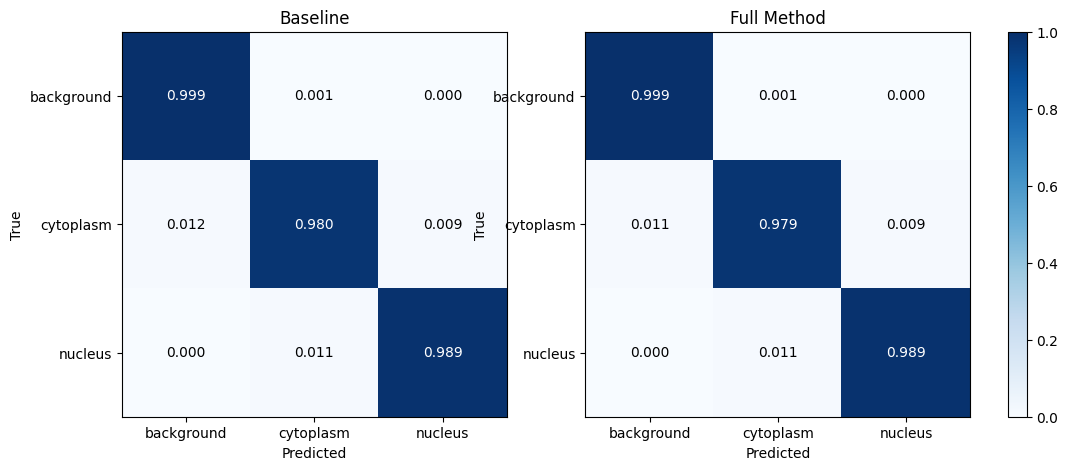

In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, title, ax, class_names=("background", "cytoplasm", "nucleus")):
    cm_normalized = cm / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            text_color = "white" if cm_normalized[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm_normalized[i, j]:.3f}",
                     ha="center", va="center", color=text_color)

    return im


FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = plot_confusion_matrix(baseline_cm, "Baseline", axes[0])
im2 = plot_confusion_matrix(full_method_cm, "Full Method", axes[1])

fig.colorbar(im1, ax=axes, fraction=0.046, pad=0.04)
plt.savefig(os.path.join(FIGURES_DIR, "confusion_matrix_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()



Boundary F1 score

In [ ]:
from scipy import ndimage

def extract_boundary(label_map):
    boundary = np.zeros_like(label_map, dtype=bool)
    boundary[:-1, :] |= label_map[:-1, :] != label_map[1:, :]
    boundary[1:, :] |= label_map[:-1, :] != label_map[1:, :]
    boundary[:, :-1] |= label_map[:, :-1] != label_map[:, 1:]
    boundary[:, 1:] |= label_map[:, :-1] != label_map[:, 1:]
    return boundary


def compute_boundary_f1(model, loader, tolerance=2):
    model.eval()
    total_tp_precision = 0
    total_pred_boundary = 0
    total_tp_recall = 0
    total_true_boundary = 0

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = msks.numpy()

            for i in range(preds.shape[0]):
                pred_map = preds[i]
                true_map = targets[i]

                pred_boundary = extract_boundary(pred_map)
                true_boundary = extract_boundary(true_map)

                true_boundary_dist = ndimage.distance_transform_edt(~true_boundary)
                pred_boundary_dist = ndimage.distance_transform_edt(~pred_boundary)

                total_tp_precision += np.sum(pred_boundary & (true_boundary_dist <= tolerance))
                total_pred_boundary += pred_boundary.sum()

                total_tp_recall += np.sum(true_boundary & (pred_boundary_dist <= tolerance))
                total_true_boundary += true_boundary.sum()

    precision = total_tp_precision / total_pred_boundary if total_pred_boundary > 0 else 0
    recall = total_tp_recall / total_true_boundary if total_true_boundary > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {"boundary_precision": precision, "boundary_recall": recall, "boundary_f1": f1}


print("computing boundary F1 (tolerance=2px)...")
baseline_boundary = compute_boundary_f1(baseline_model, test_loader)
full_method_boundary = compute_boundary_f1(full_method_model, test_loader)

print("BASELINE:", baseline_boundary)
print("FULL METHOD:", full_method_boundary)


computing boundary F1 (tolerance=2px)...
BASELINE: {'boundary_precision': np.float64(0.9823148434428253), 'boundary_recall': np.float64(0.9779985648449906), 'boundary_f1': np.float64(0.9801519522861553)}
FULL METHOD: {'boundary_precision': np.float64(0.978252724289671), 'boundary_recall': np.float64(0.9782302416409667), 'boundary_f1': np.float64(0.9782414828361408)}


Entropy calibration

In [ ]:
def compute_predictive_entropy(logits):
    probs = F.softmax(logits, dim=1)
    entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
    return entropy


def compute_entropy_calibration(model, loader):
    model.eval()
    total_entropy_correct = 0.0
    total_entropy_incorrect = 0.0
    n_correct = 0
    n_incorrect = 0

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            msks = msks.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            entropy = compute_predictive_entropy(logits)

            correct_mask = preds == msks
            incorrect_mask = ~correct_mask

            total_entropy_correct += entropy[correct_mask].sum().item()
            total_entropy_incorrect += entropy[incorrect_mask].sum().item()
            n_correct += correct_mask.sum().item()
            n_incorrect += incorrect_mask.sum().item()

    return {
        "mean_entropy_correct": total_entropy_correct / n_correct if n_correct > 0 else 0,
        "mean_entropy_incorrect": total_entropy_incorrect / n_incorrect if n_incorrect > 0 else 0,
        "n_correct": n_correct,
        "n_incorrect": n_incorrect,
    }


print("computing entropy calibration...")
baseline_entropy_cal = compute_entropy_calibration(baseline_model, test_loader)
full_method_entropy_cal = compute_entropy_calibration(full_method_model, test_loader)

print("BASELINE:", baseline_entropy_cal)
print("FULL METHOD:", full_method_entropy_cal)


computing entropy calibration...
BASELINE: {'mean_entropy_correct': 0.0026199492586003142, 'mean_entropy_incorrect': 0.3493062425513853, 'n_correct': 400682224, 'n_incorrect': 948176}
FULL METHOD: {'mean_entropy_correct': 0.003116191943260119, 'mean_entropy_incorrect': 0.3645227016470325, 'n_correct': 400618215, 'n_incorrect': 1012185}


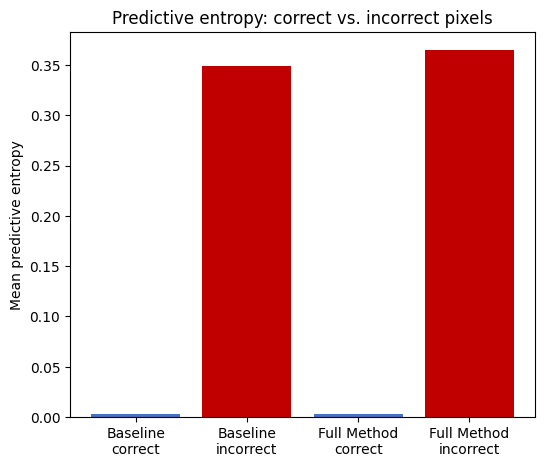

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["Baseline\ncorrect", "Baseline\nincorrect", "Full Method\ncorrect", "Full Method\nincorrect"]
values = [
    baseline_entropy_cal["mean_entropy_correct"],
    baseline_entropy_cal["mean_entropy_incorrect"],
    full_method_entropy_cal["mean_entropy_correct"],
    full_method_entropy_cal["mean_entropy_incorrect"],
]
colors = ["#4472C4", "#C00000", "#4472C4", "#C00000"]

ax.bar(labels, values, color=colors)
ax.set_ylabel("Mean predictive entropy")
ax.set_title("Predictive entropy: correct vs. incorrect pixels")
plt.savefig(os.path.join(FIGURES_DIR, "entropy_calibration.png"), dpi=200, bbox_inches="tight")
plt.show()


Per-image ratio computation

In [ ]:
def compute_ratios(model, loader):
    model.eval()
    pred_ratios = []
    true_ratios = []

    with torch.no_grad():
        for imgs, msks in loader:
            imgs = imgs.to(device)
            msks = msks.to(device)
            logits = model(imgs)
            probs = F.softmax(logits, dim=1)

            pred_nuc = probs[:, 2].sum(dim=[1, 2])
            pred_cyto = probs[:, 1].sum(dim=[1, 2])
            pred_ratio = torch.log((pred_nuc + 1e-6) / (pred_cyto + 1e-6))

            true_nuc = (msks == 2).float().sum(dim=[1, 2])
            true_cyto = (msks == 1).float().sum(dim=[1, 2])
            true_ratio = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))

            pred_ratios.append(pred_ratio.cpu().numpy())
            true_ratios.append(true_ratio.cpu().numpy())

    return np.concatenate(pred_ratios), np.concatenate(true_ratios)


print("computing per-image ratios...")
baseline_pred_ratio, baseline_true_ratio = compute_ratios(baseline_model, test_loader)
full_method_pred_ratio, full_method_true_ratio = compute_ratios(full_method_model, test_loader)

print("baseline: n =", len(baseline_pred_ratio))
print("full method: n =", len(full_method_pred_ratio))


computing per-image ratios...
baseline: n = 3099
full method: n = 3099


Bland-Altman plot

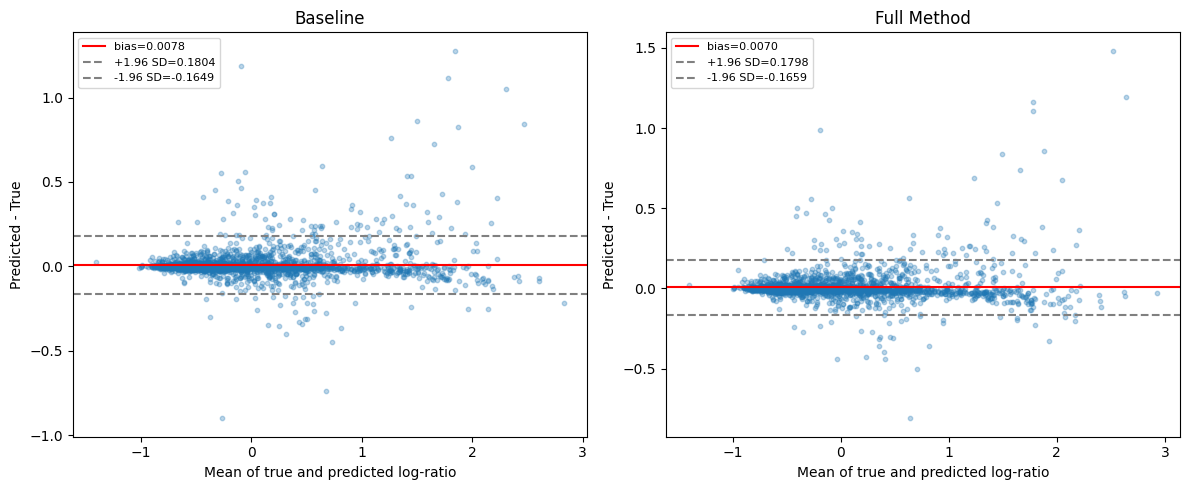

Baseline: bias=0.0078, LoA=[-0.1649, 0.1804]
Full Method: bias=0.0070, LoA=[-0.1659, 0.1798]


In [ ]:
def bland_altman_plot(true_vals, pred_vals, title, ax):
    mean_vals = (true_vals + pred_vals) / 2
    diff_vals = pred_vals - true_vals
    bias = diff_vals.mean()
    std_diff = diff_vals.std()
    upper_loa = bias + 1.96 * std_diff
    lower_loa = bias - 1.96 * std_diff

    ax.scatter(mean_vals, diff_vals, alpha=0.3, s=10)
    ax.axhline(bias, color="red", linestyle="-", label=f"bias={bias:.4f}")
    ax.axhline(upper_loa, color="gray", linestyle="--", label=f"+1.96 SD={upper_loa:.4f}")
    ax.axhline(lower_loa, color="gray", linestyle="--", label=f"-1.96 SD={lower_loa:.4f}")
    ax.set_xlabel("Mean of true and predicted log-ratio")
    ax.set_ylabel("Predicted - True")
    ax.set_title(title)
    ax.legend(fontsize=8)

    return bias, std_diff, upper_loa, lower_loa


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
baseline_stats = bland_altman_plot(baseline_true_ratio, baseline_pred_ratio, "Baseline", axes[0])
full_method_stats = bland_altman_plot(full_method_true_ratio, full_method_pred_ratio, "Full Method", axes[1])
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "bland_altman.png"), dpi=200, bbox_inches="tight")
plt.show()

print("Baseline: bias=%.4f, LoA=[%.4f, %.4f]" % (baseline_stats[0], baseline_stats[3], baseline_stats[2]))
print("Full Method: bias=%.4f, LoA=[%.4f, %.4f]" % (full_method_stats[0], full_method_stats[3], full_method_stats[2]))


ICC for ratio agreement

In [ ]:
!pip install -q pingouin
import pingouin as pg

def compute_icc(true_vals, pred_vals):
    n = len(true_vals)
    df = pd.DataFrame({
        "image": list(range(n)) * 2,
        "rater": ["true"] * n + ["predicted"] * n,
        "ratio": np.concatenate([true_vals, pred_vals]),
    })
    icc_result = pg.intraclass_corr(data=df, targets="image", raters="rater", ratings="ratio")
    return icc_result

print("=== BASELINE ICC ===")
print(compute_icc(baseline_true_ratio, baseline_pred_ratio))

print("")
print("=== FULL METHOD ICC ===")
print(compute_icc(full_method_true_ratio, full_method_pred_ratio))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.8 MB/s eta 0:00:00
=== BASELINE ICC ===
       Type       ICC           F   df1   df2  pval          CI95
0  ICC(1,1)  0.989904  197.103742  3098  3099   0.0  [0.99, 0.99]
1  ICC(A,1)  0.989905  198.571351  3098  3098   0.0  [0.99, 0.99]
2  ICC(C,1)  0.989979  198.571351  3098  3098   0.0  [0.99, 0.99]
3  ICC(1,k)  0.994927  197.103742  3098  3099   0.0   [0.99, 1.0]
4  ICC(A,k)  0.994927  198.571351  3098  3098   0.0   [0.99, 1.0]
5  ICC(C,k)  0.994964  198.571351  3098  3098   0.0   [0.99, 1.0]

=== FULL METHOD ICC ===
       Type       ICC           F   df1   df2  pval          CI95
0  ICC(1,1)  0.989849  196.023320  3098  3099   0.0  [0.99, 0.99]
1  ICC(A,1)  0.989849  197.180869  3098  3098   0.0  [0.99, 0.99]
2  ICC(C,1)  0.989908  197.180869  3098  3098   0.0  [0.99, 0.99]
3  ICC(1,k)  0.994899  196.023320  3098  3099   0.0   [0.99, 1.0]
4  ICC(A,k)  0.994899  197.180869  3098  3098   0.0   [0.99, 1.0]
5  ICC(C,k)  0.

Load U-Net checkpoints, RFG off / RFG on

In [ ]:
unet_rfg_off_model = load_checkpoint("unet", use_rfg=False, use_ratio=True, seed=2)
unet_rfg_on_model = load_checkpoint("unet", use_rfg=True, use_ratio=True, seed=2)


loaded unet_rfg0_ratio1_seed2
loaded unet_rfg1_ratio1_seed2


Confusion matrix

UNET RFG-OFF (rfg0_ratio1, seed2)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background 353,534,752     238,717       7,167
   cytoplasm     311,371  25,842,770     307,314
     nucleus       2,343     187,813  21,198,153

Per-class precision/recall:
  background: precision=0.9991, recall=0.9993
  cytoplasm: precision=0.9838, recall=0.9766
  nucleus: precision=0.9854, recall=0.9911

UNET RFG-ON (rfg1_ratio1, seed2)
Confusion matrix (rows=true, cols=predicted):
              background   cytoplasm     nucleus
  background 353,532,887     230,253      17,496
   cytoplasm     286,451  25,908,807     266,197
     nucleus       1,853     196,252  21,190,204

Per-class precision/recall:
  background: precision=0.9992, recall=0.9993
  cytoplasm: precision=0.9838, recall=0.9791
  nucleus: precision=0.9868, recall=0.9907


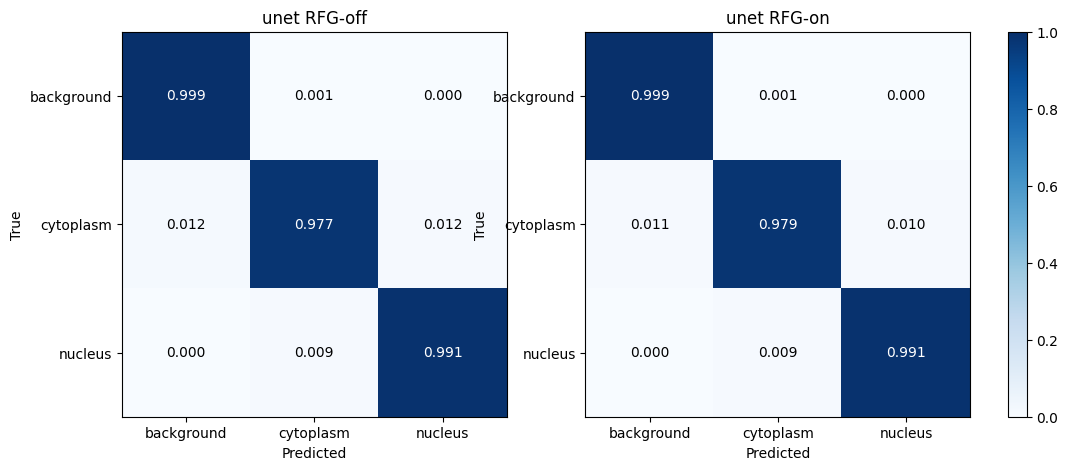

In [ ]:
print("=" * 70)
print("UNET RFG-OFF (rfg0_ratio1, seed2)")
print("=" * 70)
unet_off_cm = compute_confusion_matrix_streaming(unet_rfg_off_model, test_loader)
print_confusion_matrix(unet_off_cm)

print("")
print("=" * 70)
print("UNET RFG-ON (rfg1_ratio1, seed2)")
print("=" * 70)
unet_on_cm = compute_confusion_matrix_streaming(unet_rfg_on_model, test_loader)
print_confusion_matrix(unet_on_cm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = plot_confusion_matrix(unet_off_cm, "unet RFG-off", axes[0])
im2 = plot_confusion_matrix(unet_on_cm, "unet RFG-on", axes[1])
fig.colorbar(im1, ax=axes, fraction=0.046, pad=0.04)
plt.savefig(os.path.join(FIGURES_DIR, "confusion_matrix_unet.png"), dpi=100, bbox_inches="tight")
plt.show()


Boundary F1 score

In [ ]:
print("computing boundary F1 (tolerance=2px)...")
unet_off_boundary = compute_boundary_f1(unet_rfg_off_model, test_loader)
unet_on_boundary = compute_boundary_f1(unet_rfg_on_model, test_loader)

print("UNET RFG-OFF:", unet_off_boundary)
print("UNET RFG-ON:", unet_on_boundary)


computing boundary F1 (tolerance=2px)...
UNET RFG-OFF: {'boundary_precision': np.float64(0.9777927534967878), 'boundary_recall': np.float64(0.977059446404159), 'boundary_f1': np.float64(0.9774259624108446)}
UNET RFG-ON: {'boundary_precision': np.float64(0.9804693305030056), 'boundary_recall': np.float64(0.9777896420200479), 'boundary_f1': np.float64(0.9791276528139423)}


Entropy calibration

In [ ]:
print("computing entropy calibration...")
unet_off_entropy = compute_entropy_calibration(unet_rfg_off_model, test_loader)
unet_on_entropy = compute_entropy_calibration(unet_rfg_on_model, test_loader)

print("UNET RFG-OFF:", unet_off_entropy)
print("UNET RFG-ON:", unet_on_entropy)


computing entropy calibration...
UNET RFG-OFF: {'mean_entropy_correct': 0.0044148383109528086, 'mean_entropy_incorrect': 0.3861701170763928, 'n_correct': 400575675, 'n_incorrect': 1054725}
UNET RFG-ON: {'mean_entropy_correct': 0.0031788795182557065, 'mean_entropy_incorrect': 0.37279497507089837, 'n_correct': 400631898, 'n_incorrect': 998502}


Bland-Altman plot and ICC

computing per-image ratios...


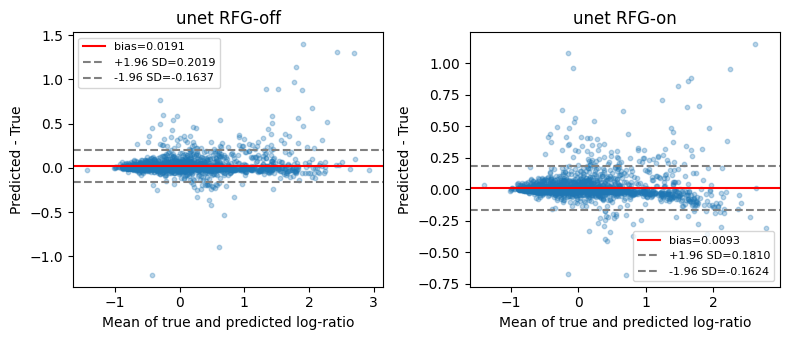

RFG-off: bias=0.0191, LoA=[-0.1637, 0.2019]
RFG-on: bias=0.0093, LoA=[-0.1624, 0.1810]

=== UNET RFG-OFF ICC ===
       Type       ICC           F   df1   df2  pval          CI95
0  ICC(1,1)  0.988410  171.566186  3098  3099   0.0  [0.99, 0.99]
1  ICC(A,1)  0.988413  178.702060  3098  3098   0.0  [0.99, 0.99]
2  ICC(C,1)  0.988870  178.702060  3098  3098   0.0  [0.99, 0.99]
3  ICC(1,k)  0.994171  171.566186  3098  3099   0.0  [0.99, 0.99]
4  ICC(A,k)  0.994173  178.702060  3098  3098   0.0  [0.99, 0.99]
5  ICC(C,k)  0.994404  178.702060  3098  3098   0.0  [0.99, 0.99]

=== UNET RFG-ON ICC ===
       Type       ICC           F   df1   df2  pval          CI95
0  ICC(1,1)  0.989863  196.289873  3098  3099   0.0  [0.99, 0.99]
1  ICC(A,1)  0.989863  198.428168  3098  3098   0.0  [0.99, 0.99]
2  ICC(C,1)  0.989971  198.428168  3098  3098   0.0  [0.99, 0.99]
3  ICC(1,k)  0.994905  196.289873  3098  3099   0.0   [0.99, 1.0]
4  ICC(A,k)  0.994906  198.428168  3098  3098   0.0   [0.99, 1.0]
5  I

In [ ]:
print("computing per-image ratios...")
unet_off_pred_ratio, unet_off_true_ratio = compute_ratios(unet_rfg_off_model, test_loader)
unet_on_pred_ratio, unet_on_true_ratio = compute_ratios(unet_rfg_on_model, test_loader)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
unet_off_stats = bland_altman_plot(unet_off_true_ratio, unet_off_pred_ratio, "unet RFG-off", axes[0])
unet_on_stats = bland_altman_plot(unet_on_true_ratio, unet_on_pred_ratio, "unet RFG-on", axes[1])
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "bland_altman_unet.png"), dpi=100, bbox_inches="tight")
plt.show()

print("RFG-off: bias=%.4f, LoA=[%.4f, %.4f]" % (unet_off_stats[0], unet_off_stats[3], unet_off_stats[2]))
print("RFG-on: bias=%.4f, LoA=[%.4f, %.4f]" % (unet_on_stats[0], unet_on_stats[3], unet_on_stats[2]))

print("")
print("=== UNET RFG-OFF ICC ===")
print(compute_icc(unet_off_true_ratio, unet_off_pred_ratio))

print("")
print("=== UNET RFG-ON ICC ===")
print(compute_icc(unet_on_true_ratio, unet_on_pred_ratio))
